# Quiz: Stochastic Processes Simulations

This notebook simulates and compares four discrete-time stochastic systems:
1. AWGN filtered by a low-pass system $H(\omega)$
2. AR(3) process
3. ARMA(3, 6) process
4. Random Walk process

Each process is represented with the same `StochasticProcess` dataclass and visualized in three domains: realization in $t$, autocorrelation in $\tau$, and PSD in $\omega$.

In [16]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch


@dataclass(frozen=True)
class StochasticProcess:
    """Stores one realization and its lag/frequency-domain summaries."""

    realization: np.ndarray  # Process samples x[t] [a.u.]
    acf: tuple[np.ndarray, np.ndarray]  # (tau_samples, R_x[tau])
    psd: tuple[np.ndarray, np.ndarray]  # (omega_rad, S_x[omega])


def welch_psd_torch(
    realization: np.ndarray,             # Input realization x[t]
    n_fft: int = 1024,                   # Number of FFT bins
    segment_length_samples: int = 256,   # Welch segment length [samples]
    overlap_samples: int = 128,          # Overlap between segments [samples]
) -> tuple[np.ndarray, np.ndarray]:      # (omega_rad, normalized_psd)
    """Estimate a two-sided Welch PSD using PyTorch FFT primitives.

    Purpose:
        Compute an averaged periodogram estimate with Hann windowing and
        overlapping segments, using PyTorch for the FFT pipeline.
    Parameters:
        realization: One-dimensional realization x[t].
        n_fft: Number of FFT bins.
        segment_length_samples: Welch window length [samples].
        overlap_samples: Overlap between adjacent windows [samples].
    Returns:
        `(omega_rad, psd_values)` where `omega_rad` is in [-pi, pi) and
        `psd_values` is normalized to unit maximum for comparison plots.
    Side effects:
        None.
    Assumptions:
        Input is real-valued and long enough for at least one Welch segment.
    """
    if realization.ndim != 1:
        raise ValueError("realization must be a 1-D array.")
    if n_fft < 16:
        raise ValueError("n_fft must be >= 16 for a meaningful PSD.")
    if segment_length_samples < 8:
        raise ValueError("segment_length_samples must be >= 8.")
    if overlap_samples < 0 or overlap_samples >= segment_length_samples:
        raise ValueError("overlap_samples must satisfy 0 <= overlap < segment_length.")

    num_samples = realization.size
    if num_samples <= segment_length_samples:
        raise ValueError("realization length must exceed segment_length_samples.")

    x_tensor = torch.as_tensor(realization, dtype=torch.float64)
    step_samples = segment_length_samples - overlap_samples

    # Build overlapping frames with index-based slicing for Welch averaging.
    segment_starts = torch.arange(
        0,
        num_samples - segment_length_samples + 1,
        step_samples,
        dtype=torch.int64,
    )
    if int(segment_starts.numel()) == 0:
        raise RuntimeError("Welch PSD failed: no valid segments were generated.")

    frame_offsets = torch.arange(segment_length_samples, dtype=torch.int64)
    frame_indices = segment_starts[:, None] + frame_offsets[None, :]
    segments = x_tensor[frame_indices]

    # Apply Hann window and average two-sided periodograms in the FFT domain.
    window = torch.hann_window(segment_length_samples, periodic=False, dtype=torch.float64)
    window_power = torch.sum(window**2).clamp_min(torch.finfo(torch.float64).eps)
    spectra = torch.fft.fft(segments * window.unsqueeze(0), n=n_fft, dim=1)
    periodograms = torch.abs(spectra) ** 2 / window_power
    psd_two_sided = torch.mean(periodograms, dim=0)

    # Shift to [-pi, pi) and normalize amplitude for consistent visualization.
    psd_shifted = torch.fft.fftshift(psd_two_sided)
    psd_values = psd_shifted / torch.max(psd_shifted).clamp_min(torch.finfo(torch.float64).eps)
    omega_rad = torch.linspace(-torch.pi, torch.pi, n_fft + 1, dtype=torch.float64)[:-1]

    return omega_rad.cpu().numpy(), psd_values.cpu().numpy()


def estimate_acf_psd(
    realization: np.ndarray,             # Process samples x[t]
    max_lag_samples: int = 128,          # Maximum lag for ACF [samples]
    n_fft: int = 1024,                   # Frequency bins for PSD estimation
    segment_length_samples: int = 256,   # Welch segment length [samples]
    overlap_samples: int = 128,          # Overlap between Welch segments [samples]
) -> tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]:
    """Estimate normalized ACF and Welch PSD from one realization.

    Purpose:
        Build an empirical autocorrelation around tau=0 and estimate the PSD
        with Welch's method (windowed averaged periodograms).
    Parameters:
        realization: One-dimensional realization x[t].
        max_lag_samples: Number of positive/negative lags to keep [samples].
        n_fft: Number of frequency samples for PSD discretization.
        segment_length_samples: Welch segment length [samples].
        overlap_samples: Overlap between adjacent Welch segments [samples].
    Returns:
        A pair `(acf, psd)` where:
        - `acf = (tau_samples, R_x[tau])` with normalized R_x[0] = 1.
        - `psd = (omega_rad, S_x[omega])` from Welch, normalized to max value 1.
    Side effects:
        None.
    Assumptions:
        Input is real-valued and long enough for requested lag and Welch window.
    """
    if realization.ndim != 1:
        raise ValueError("realization must be a 1-D array.")
    if max_lag_samples < 1:
        raise ValueError("max_lag_samples must be >= 1.")

    x_centered = realization - np.mean(realization)
    num_samples = x_centered.size

    # Compute full empirical autocorrelation and keep a symmetric lag window.
    acf_full = np.correlate(x_centered, x_centered, mode="full") / num_samples
    lags_full = np.arange(-num_samples + 1, num_samples)
    valid_lag_mask = np.abs(lags_full) <= min(max_lag_samples, num_samples - 1)
    tau_samples = lags_full[valid_lag_mask]
    acf_values = acf_full[valid_lag_mask]

    # Normalize ACF by zero-lag value for easier comparison across processes.
    acf_zero = float(acf_values[tau_samples == 0][0])
    acf_values = acf_values / max(acf_zero, np.finfo(float).eps)

    # Estimate Welch PSD through the dedicated PyTorch implementation.
    omega_rad, psd_values = welch_psd_torch(
        realization=x_centered,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )

    return (tau_samples.astype(np.int64), acf_values), (omega_rad, psd_values)


def build_lowpass_fir(
    num_taps: int,                # Number of FIR taps
    cutoff_rad: float,            # Cutoff angular frequency [rad/sample]
) -> np.ndarray:                  # Low-pass FIR impulse response h[t]
    """Design a windowed-sinc low-pass FIR with unit gain at DC."""
    if num_taps % 2 == 0:
        raise ValueError("num_taps must be odd for linear-phase centering.")
    if not 0.0 < cutoff_rad < np.pi:
        raise ValueError("cutoff_rad must satisfy 0 < cutoff_rad < pi.")

    # Build an ideal low-pass and taper it with a Hamming window.
    n = np.arange(num_taps) - (num_taps - 1) / 2
    normalized_cutoff = cutoff_rad / np.pi
    h = normalized_cutoff * np.sinc(normalized_cutoff * n)
    h *= np.hamming(num_taps)

    # Normalize to keep DC gain equal to 1 after filtering.
    h /= np.sum(h)
    return h


def simulate_filtered_awgn(
    num_samples: int,             # Number of output samples
    rng: np.random.Generator,     # Random generator for reproducibility
    cutoff_rad: float,            # LPF cutoff [rad/sample]
    num_taps: int = 41,           # FIR length
) -> np.ndarray:                 # Filtered AWGN realization x[t]
    """Generate AWGN passed through a low-pass FIR system H(omega)."""
    h = build_lowpass_fir(num_taps=num_taps, cutoff_rad=cutoff_rad)

    # Pad input noise so convolution can return exactly num_samples points.
    white_noise = rng.standard_normal(num_samples + num_taps - 1)
    filtered_noise = np.convolve(white_noise, h, mode="valid")
    return filtered_noise[:num_samples]


def simulate_ar_process(
    num_samples: int,             # Number of output samples
    ar_coeffs: np.ndarray,        # AR coefficients [a1, ..., ap]
    rng: np.random.Generator,     # Random generator for innovation noise
    noise_std: float = 1.0,       # Innovation standard deviation
    burn_in_samples: int = 500,   # Warm-up samples to reduce transients
) -> np.ndarray:                 # AR realization x[t]
    """Simulate x[t] = sum_k a_k x[t-k] + w[t] for a stable AR model."""
    p_order = int(ar_coeffs.size)
    total_samples = num_samples + burn_in_samples + p_order
    innovations = noise_std * rng.standard_normal(total_samples)
    x = np.zeros(total_samples)

    # Recursively build AR samples from past outputs and current innovation.
    for idx in range(p_order, total_samples):
        ar_term = float(ar_coeffs @ x[idx - p_order:idx][::-1]) if p_order else 0.0
        x[idx] = ar_term + innovations[idx]

    start_idx = burn_in_samples + p_order
    return x[start_idx:start_idx + num_samples]


def simulate_arma_process(
    num_samples: int,             # Number of output samples
    ar_coeffs: np.ndarray,        # AR coefficients [a1, ..., ap]
    ma_coeffs: np.ndarray,        # MA coefficients [b1, ..., bq]
    rng: np.random.Generator,     # Random generator for innovation noise
    noise_std: float = 1.0,       # Innovation standard deviation
    burn_in_samples: int = 500,   # Warm-up samples to reduce transients
) -> np.ndarray:                 # ARMA realization x[t]
    """Simulate x[t] = sum_k a_k x[t-k] + w[t] + sum_l b_l w[t-l]."""
    p_order = int(ar_coeffs.size)
    q_order = int(ma_coeffs.size)
    max_order = max(p_order, q_order)

    total_samples = num_samples + burn_in_samples + max_order
    innovations = noise_std * rng.standard_normal(total_samples)
    x = np.zeros(total_samples)

    # Recursively combine AR memory with MA colored innovation term.
    for idx in range(max_order, total_samples):
        ar_term = float(ar_coeffs @ x[idx - p_order:idx][::-1]) if p_order else 0.0
        ma_term = float(ma_coeffs @ innovations[idx - q_order:idx][::-1]) if q_order else 0.0
        x[idx] = ar_term + innovations[idx] + ma_term

    start_idx = burn_in_samples + max_order
    return x[start_idx:start_idx + num_samples]


def simulate_random_walk(
    num_samples: int,             # Number of output samples
    rng: np.random.Generator,     # Random generator for incremental noise
    step_std: float = 1.0,        # Step standard deviation
) -> np.ndarray:                 # Random walk realization x[t]
    """Generate a random walk by cumulative summation of Gaussian steps."""
    increments = step_std * rng.standard_normal(num_samples)
    return np.cumsum(increments)


def build_stochastic_process(
    realization: np.ndarray,         # Process realization x[t]
    max_lag_samples: int,            # Maximum lag for ACF [samples]
    n_fft: int,                      # Number of frequency bins for PSD
    segment_length_samples: int,     # Welch segment length [samples]
    overlap_samples: int,            # Welch overlap [samples]
) -> StochasticProcess:              # Dataclass with realization, ACF, and PSD
    """Create a StochasticProcess object from one realization."""
    acf, psd = estimate_acf_psd(
        realization=realization,
        max_lag_samples=max_lag_samples,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )
    return StochasticProcess(realization=realization, acf=acf, psd=psd)


In [17]:
rng = np.random.default_rng(seed=42)

num_samples = 2048
max_lag_samples = 160
n_fft = 2048
segment_length_samples = 256
overlap_samples = 128

# Define one realization per process family requested in the quiz statement.
realizations = {
    "Filtered AWGN (LPF)": simulate_filtered_awgn(
        num_samples=num_samples,
        rng=rng,
        cutoff_rad=0.35 * np.pi,
        num_taps=41,
    ),
    "AR(3)": simulate_ar_process(
        num_samples=num_samples,
        ar_coeffs=np.array([0.75, -0.30, 0.12]),
        rng=rng,
        noise_std=1.0,
        burn_in_samples=600,
    ),
    "ARMA(3,6)": simulate_arma_process(
        num_samples=num_samples,
        ar_coeffs=np.array([0.70, -0.28, 0.10]),
        ma_coeffs=np.array([0.65, 0.30, -0.18, 0.10, 0.05, -0.03]),
        rng=rng,
        noise_std=1.0,
        burn_in_samples=600,
    ),
    "Random Walk": simulate_random_walk(
        num_samples=num_samples,
        rng=rng,
        step_std=1.0,
    ),
}

processes = {
    name: build_stochastic_process(
        realization=realization,
        max_lag_samples=max_lag_samples,
        n_fft=n_fft,
        segment_length_samples=segment_length_samples,
        overlap_samples=overlap_samples,
    )
    for name, realization in realizations.items()
}

list(processes.keys())


['Filtered AWGN (LPF)', 'AR(3)', 'ARMA(3,6)', 'Random Walk']

Text(0.5, 0.98, 'Stochastic Processes in t, tau, and omega Domains')

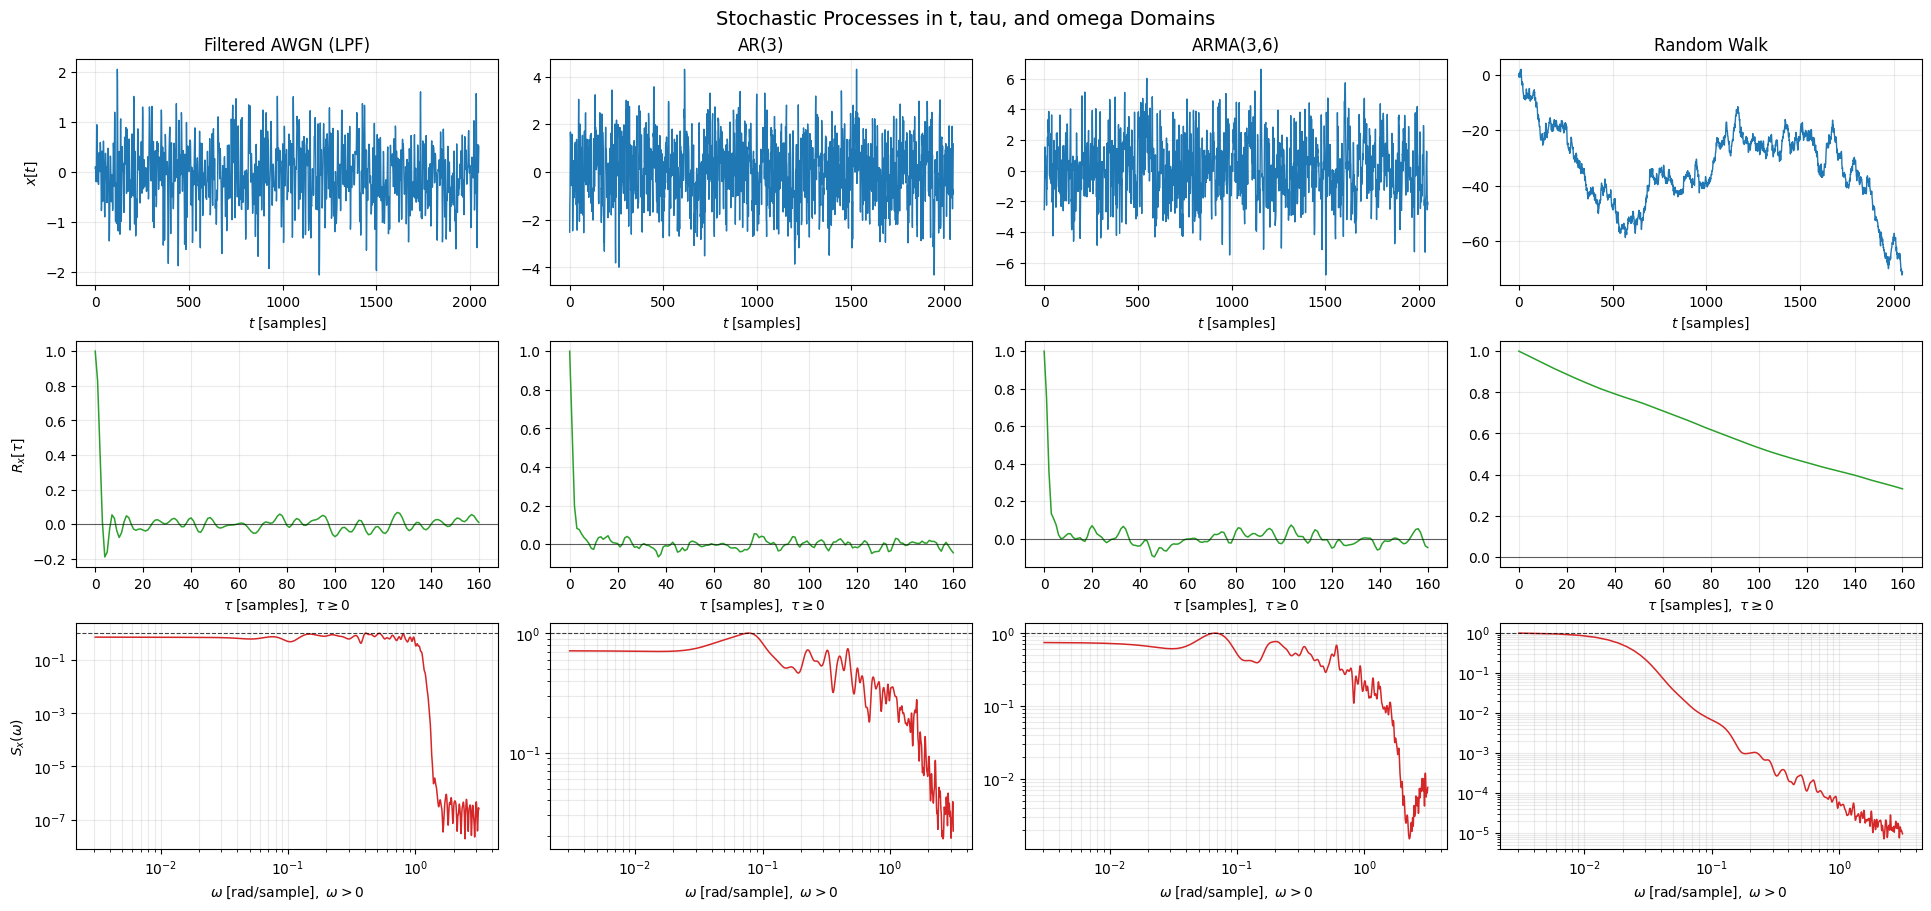

In [18]:
process_names = list(processes.keys())
num_processes = len(process_names)

fig, axes = plt.subplots(
    nrows=3,
    ncols=num_processes,
    figsize=(4.8 * num_processes, 9.0),
    constrained_layout=True,
)

# Keep a 2-D indexing shape even when there is only one process.
if num_processes == 1:
    axes = axes.reshape(3, 1)

for col, process_name in enumerate(process_names):
    process = processes[process_name]

    # Row 1: time-domain realization x[t].
    t_samples = np.arange(process.realization.size)
    ax_t = axes[0, col]
    ax_t.plot(t_samples, process.realization, color="tab:blue", linewidth=1.0)
    ax_t.set_title(process_name)
    ax_t.set_xlabel(r"$t\;[\mathrm{samples}]$")
    if col == 0:
        ax_t.set_ylabel(r"$x[t]$")
    ax_t.grid(alpha=0.25)

    # Row 2: lag-domain autocorrelation R_x[tau] (non-negative lags only).
    tau_samples, acf_values = process.acf
    nonnegative_lag_mask = tau_samples >= 0
    tau_nonnegative = tau_samples[nonnegative_lag_mask]
    acf_nonnegative = acf_values[nonnegative_lag_mask]

    ax_tau = axes[1, col]
    ax_tau.plot(tau_nonnegative, acf_nonnegative, color="tab:green", linewidth=1.1)
    ax_tau.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    ax_tau.set_xlabel(r"$\tau\;[\mathrm{samples}],\ \tau \geq 0$")
    if col == 0:
        ax_tau.set_ylabel(r"$R_x[\tau]$")
    ax_tau.grid(alpha=0.25)

    # Row 3: PSD S_x[omega] on log-log axes, positive frequencies only.
    omega_rad, psd_values = process.psd
    positive_freq_mask = omega_rad > 0.0
    omega_pos = omega_rad[positive_freq_mask]
    psd_pos = np.maximum(psd_values[positive_freq_mask], np.finfo(float).eps)

    ax_omega = axes[2, col]
    ax_omega.loglog(omega_pos, psd_pos, color="tab:red", linewidth=1.1)
    # 0 dB corresponds to normalized power level 1.0.
    ax_omega.axhline(1.0, color="black", linestyle="--", linewidth=0.8, alpha=0.75)
    ax_omega.set_xlabel(r"$\omega\;[\mathrm{rad/sample}],\ \omega > 0$")
    if col == 0:
        ax_omega.set_ylabel(r"$S_x(\omega)$")
    ax_omega.grid(alpha=0.25, which="both")

fig.suptitle("Stochastic Processes in t, tau, and omega Domains", fontsize=14)


Analyze whether
$$
r_x(\lambda)=\sum_{k=-K}^{K} w_k\,e^{-\alpha_k\lambda^2},\qquad w_k\ge 0
$$
can be a valid autocorrelation function (ACF).

In [ ]:
# ACF VALIDATION GOES HERE